# Mimir health -- general status

How Mimir is doing right now: component health, request errors, ruler/alertmanager,
storage, plus **logs** (Loki), **firing alerts**, and the **apprise delivery backend**
as cross-checks from independent points of view. This notebook uses the LGTM stack normally and assumes it basically
works; [mimir-nolgtm.ipynb](mimir-nolgtm.ipynb) is the tool for when Mimir is unhappy
and can't answer questions about itself. Capacity/tenants: [mimir-usage.ipynb](mimir-usage.ipynb).

Checks are informed by the deployed mimir mixin's alert groups (`mimir_alerts` et al).
Design: [tiles#644](https://github.com/symmatree/tiles/issues/644),
[docs/mimir.md](../docs/mimir.md),
`facts/notebook-analysis/design-intent.md`.

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace mimir-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"
loki_url = "http://loki.loki.svc:3100"
tenant = "tiles"       # X-Scope-OrgID for Mimir and Loki
namespace = "mimir"    # namespace scoping for logs, alerts, kube metrics
lookback_hours = 24
range_step_s = 300
log_sample_lines = 100
capture_file = ""      # replay a prior raw capture JSON instead of querying live
output_dir = ""        # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'mimir-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url,
                  tenant=tenant, namespace=namespace, lookback_hours=lookback_hours,
                  range_step_s=range_step_s, log_sample_lines=log_sample_lines)
tenant, namespace = cap.meta['tenant'], cap.meta['namespace']
lookback_hours, step = cap.meta['lookback_hours'], cap.meta['range_step_s']
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)
lk = nbc.Loki(cap, cap.meta['loki_url'], tenant)
print(f"mimir: {cap.meta['mimir_url']}  loki: {cap.meta['loki_url']}  tenant: {tenant}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  live


In [3]:
# --- ASSUMPTIONS: verify the instruments before trusting any reading ---
# Fatal (whole notebook unassessable): Mimir unreachable, or its self-monitoring
# absent/stale -- the tiles#556 mode where cortex_* is exposed but scraped by
# nothing, so a dead pipeline reads as healthy. Non-fatal: kube_*/cadvisor/Loki
# gaps degrade only their own sections.
assumption_warnings = []
fatal = []
STALE_S = 600

binfo = mm.get('buildinfo', '/prometheus/api/v1/status/buildinfo')
mimir_version = binfo.get('json', {}).get('data', {}).get('version', 'unknown')

freshness = {
    'cortex self-monitoring': 'max(timestamp(cortex_ingester_memory_series))',
    'kube-state-metrics (mimir ns)': f'max(timestamp(kube_pod_info{{namespace="{namespace}"}}))',
    'cadvisor (mimir ns)': f'max(timestamp(container_memory_working_set_bytes{{namespace="{namespace}"}}))',
}
inst_age = {}
for inst, query in freshness.items():
    ts = nbc.val(mm.q(f'fresh: {inst}', query))
    inst_age[inst] = cap.now - ts if not np.isnan(ts) else np.inf
try:
    probe = lk.lines('fresh: loki (mimir ns)', f'{{namespace="{namespace}"}}', 1, 1)
    inst_age['loki (mimir ns logs)'] = cap.now - probe[0][0].timestamp() if probe else np.inf
except Exception as e:
    inst_age['loki (mimir ns logs)'] = np.inf

print("=== ASSUMPTIONS ===")
print(f"  mimir {mimir_version} at {cap.meta['mimir_url']}: reachable")
for inst, age in inst_age.items():
    status = 'MISSING' if np.isinf(age) else f"newest sample {age:.0f}s old" + (' -- STALE' if age > STALE_S else '')
    print(f"  {inst}: {status}")
    if age > STALE_S:
        msg = f"{inst}: {'absent' if np.isinf(age) else f'stale ({age:.0f}s)'}"
        (fatal if inst.startswith('cortex') else assumption_warnings).append(msg)

if fatal:
    raise RuntimeError("unassessable -- self-monitoring untrustworthy: " + "; ".join(fatal))
for w in assumption_warnings:
    print(f"  WARNING: {w} -- dependent section unassessable")
if not assumption_warnings:
    print("  all ok")

=== ASSUMPTIONS ===
  mimir 3.0.1 at http://mimir-gateway.mimir.svc: reachable
  cortex self-monitoring: newest sample 4s old
  kube-state-metrics (mimir ns): newest sample 53s old
  cadvisor (mimir ns): newest sample 12s old
  loki (mimir ns logs): newest sample 0s old
  all ok


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis,
# so a broken analysis cell cannot cost us the raw snapshot.
up_ok = nbc.by(mm.q('up_ok_by_job', f'sum by (job) (up{{namespace="{namespace}"}})'), 'job')
up_all = nbc.by(mm.q('up_targets_by_job', f'count by (job) (up{{namespace="{namespace}"}})'), 'job')
restarts = nbc.by(mm.q('restarts_by_pod', f'sum by (pod) (kube_pod_container_status_restarts_total{{namespace="{namespace}"}})'), 'pod')
last_term = mm.q('last_terminated_reason', f'kube_pod_container_status_last_terminated_reason{{namespace="{namespace}"}} == 1')
mem_ws = nbc.by(mm.q('mem_working_set_by_pod', f'sum by (pod) (container_memory_working_set_bytes{{namespace="{namespace}", container!=""}})'), 'pod')
mem_lim = nbc.by(mm.q('mem_limit_by_pod', f'sum by (pod) (kube_pod_container_resource_limits{{namespace="{namespace}", resource="memory"}})'), 'pod')
ring_unhealthy = nbc.by(mm.q('ring_members_unhealthy', 'sum by (name) (cortex_ring_members{state="Unhealthy"})'), 'name')
compactor_last = nbc.val(mm.q('compactor_last_success', 'max(cortex_compactor_last_successful_run_timestamp_seconds)'))

# --- delivery backend (apprise ns): alerting's whole point. The alert-forward
# sidecar in mimir-alertmanager only reformats + forwards to this shared apprise
# deployment, so it is the one downstream dependency worth checking from here.
# No up/ready KSM series is collected for it, so use phase + restarts.
apprise_ns = 'apprise'
apprise_running = nbc.by(mm.q('apprise_pods_running', f'sum by (pod) (kube_pod_status_phase{{namespace="{apprise_ns}", phase="Running"}})'), 'pod')
apprise_restarts = nbc.by(mm.q('apprise_restarts', f'sum by (pod) (kube_pod_container_status_restarts_total{{namespace="{apprise_ns}"}})'), 'pod')

f_errratio = nbc.frame(mm.qr('request_error_ratio_by_route',
    'sum by (route) (rate(cortex_request_duration_seconds_count{status_code=~"5..|error"}[5m]))'
    ' / sum by (route) (rate(cortex_request_duration_seconds_count[5m]))',
    lookback_hours, step), 'route')
f_evals = nbc.frame(mm.qr('rule_evals', 'sum(rate(cortex_prometheus_rule_evaluations_total[5m]))', lookback_hours, step), None)
f_evalfail = nbc.frame(mm.qr('rule_eval_failures', 'sum(rate(cortex_prometheus_rule_evaluation_failures_total[5m]))', lookback_hours, step), None)
f_notif = nbc.frame(mm.qr('am_notifications_by_integration', 'sum by (integration) (rate(cortex_alertmanager_notifications_total[5m]))', lookback_hours, step), 'integration')
f_notif_fail = nbc.frame(mm.qr('am_notification_failures', 'sum(rate(cortex_alertmanager_notifications_failed_total[5m]))', lookback_hours, step), None)

# alerts: Alertmanager API and the ruler's ALERTS series -- two views of one fact
am_alerts = cap.http('am_alerts',
                     f"{cap.meta['mimir_url']}/alertmanager/api/v2/alerts",
                     headers={'X-Scope-OrgID': tenant}).get('json', [])
alerts_now = mm.q('alerts_firing_now', 'count by (alertname, namespace) (ALERTS{alertstate="firing"})')
alerts_ns_24h = mm.q('alerts_mimir_ns_24h',
                     f'count by (alertname) (last_over_time(ALERTS{{alertstate="firing", namespace="{namespace}"}}[24h]))')
alerts_all_24h = mm.q('alerts_all_24h',
                      'count by (alertname, namespace) (last_over_time(ALERTS{alertstate="firing"}[24h]))')

# logs (Loki)
f_loglevel = nbc.frame(lk.metric_range('log_level_counts',
    f'sum by (detected_level) (count_over_time({{namespace="{namespace}"}}[10m]))',
    lookback_hours, 600), 'detected_level')
# detected_level is structured metadata, not an index label: filter as a
# pipeline stage, never in the stream selector (selector silently matches nothing).
log_errwarn = lk.lines('log_errwarn',
    f'{{namespace="{namespace}"}} | detected_level=~"error|warn"', lookback_hours, 50)
log_tail = lk.lines('log_tail', f'{{namespace="{namespace}"}}', 1,
                    cap.meta['log_sample_lines'])

# apprise delivery outcomes, from its own logs -- the only place the per-target
# result lives. mimir's webhook metric only sees the sidecar HTTP status; it cannot
# see Gmail-ok-while-Slack-fails, nor a no-tag POST that matches zero targets and
# delivers nothing. 'not sent' = >=1 matched target failed (or none matched);
# 'Delivered Notification' = all matched targets succeeded.
f_deliv = nbc.frame(lk.metric_range('apprise_delivered',
    f'sum(count_over_time({{namespace="{apprise_ns}"}} |= `Delivered Notification` [10m]))', lookback_hours, 600), None)
f_notsent = nbc.frame(lk.metric_range('apprise_not_sent',
    f'sum(count_over_time({{namespace="{apprise_ns}"}} |= `not sent` [10m]))', lookback_hours, 600), None)
apprise_tail = lk.lines('apprise_tail', f'{{namespace="{apprise_ns}"}}', lookback_hours, 12)

print(f"captured {len(cap.data['calls'])} calls, ~{len(json.dumps(cap.data)) / 1024:.0f} KB raw")

captured 30 calls, ~171 KB raw


scrape targets DOWN: ['mimir/gateway']
                                           mem_mb  limit_mb  restarts  mem_pct last_term
mimir-kafka-0                                 342         -         0        -         -
mimir-ingester-0                              301         -         9        -     Error
mimir-ingester-1                              264         -         2        -     Error
mimir-store-gateway-0                         226         -         2        -     Error
mimir-ruler-748b9f9c9c-zq4d7                   92         -         0        -         -
mimir-alertmanager-0                           84       256         0       33         -
mimir-distributor-7ccf8d9fdf-lc5x7             76         -         3        -     Error
mimir-querier-5fffc97669-sktsb                 57         -         3        -     Error
mimir-query-frontend-7d69749c4f-bcbxw          45         -         0        -         -
mimir-compactor-0                              35         -         1  

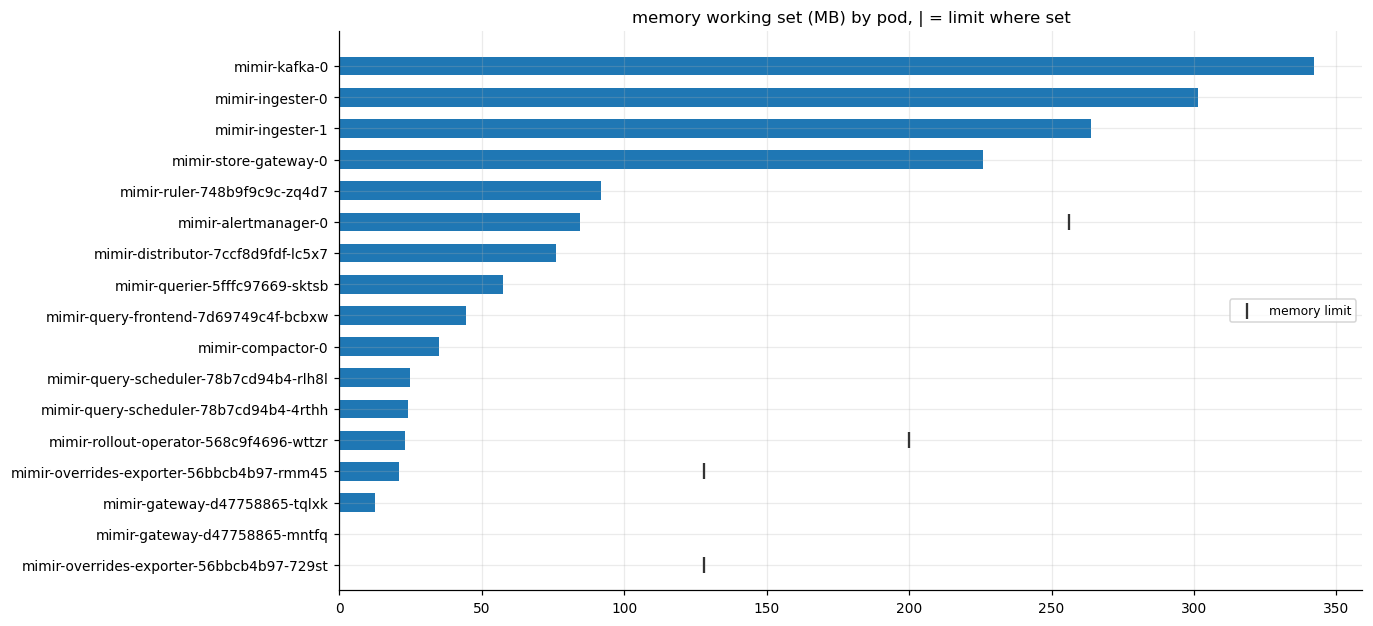

In [5]:
# --- COMPONENT HEALTH: scrape up-ness, restarts, OOMs, memory vs limits ---
scrape = pd.DataFrame({'up': pd.Series(up_ok), 'targets': pd.Series(up_all)})
scrape_down = sorted(scrape[scrape['up'] < scrape['targets']].index)
if scrape_down:
    print(f"scrape targets DOWN: {scrape_down}")
else:
    print(f"all {int(scrape['targets'].sum())} scrape targets up across {len(scrape)} jobs")

pods = pd.DataFrame({'mem_mb': pd.Series(mem_ws) / 2**20,
                     'limit_mb': pd.Series(mem_lim) / 2**20,
                     'restarts': pd.Series(restarts)})
pods['mem_pct'] = 100 * pods['mem_mb'] / pods['limit_mb']
pods['last_term'] = pd.Series({r['metric']['pod']: r['metric']['reason'] for r in last_term})
pods = pods.sort_values('mem_mb', ascending=False)
print(pods.to_string(float_format=lambda v: f'{v:,.0f}', na_rep='-'))

oom_pods = sorted(pods[pods['last_term'] == 'OOMKilled'].index)
restart_pods = {p: int(n) for p, n in pods['restarts'].items() if n > 0}
ring_bad = {k: int(v) for k, v in ring_unhealthy.items() if v > 0}
print(f"unhealthy ring members: {ring_bad or 'none'}")

# delivery backend readiness (apprise) -- a dependency, shown alongside mimir's own
apprise_pods = sorted(set(apprise_running) | set(apprise_restarts))
apprise_not_running = sorted(p for p in apprise_pods if apprise_running.get(p, 0) < 1)
apprise_restart_pods = {p: int(n) for p, n in apprise_restarts.items() if n > 0}
if not apprise_pods:
    print('delivery backend (apprise): NO PODS -- alert delivery is down')
else:
    print(f"delivery backend (apprise): {len(apprise_pods) - len(apprise_not_running)}/{len(apprise_pods)} running"
          + (f"; NOT running: {apprise_not_running}" if apprise_not_running else '')
          + (f"; restarts: {apprise_restart_pods}" if apprise_restart_pods else ''))

fig, ax = plt.subplots(figsize=(12, 0.28 * len(pods) + 1))
ax.barh(pods.index[::-1], pods['mem_mb'][::-1], color='C0', height=0.6)
lim = pods['limit_mb'].dropna()
ax.scatter(lim, [list(pods.index[::-1]).index(p) for p in lim.index],
           marker='|', s=120, color='0.2', label='memory limit', zorder=3)
ax.legend(fontsize=8)
ax.set_title('memory working set (MB) by pod, | = limit where set')
nbc.show(fig)

routes with any 5xx/error responses in window (max %): {'api_v1_push': 0.28}


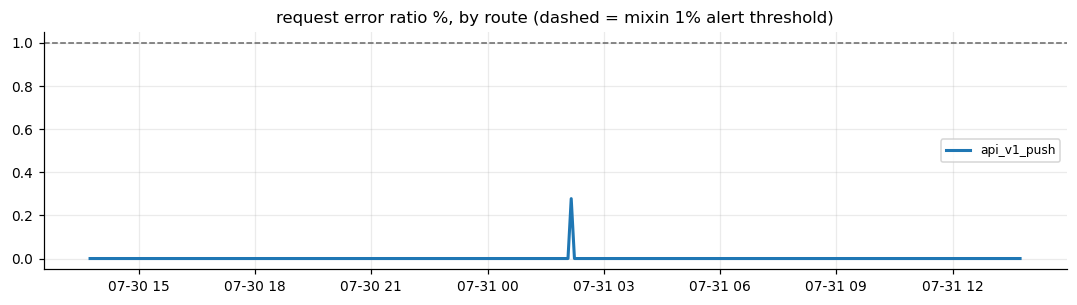

In [6]:
# --- REQUEST ERRORS (mixin: MimirRequestErrors fires at >1% 5xx for 15m) ---
err_nz = f_errratio.loc[:, f_errratio.max() > 0] if not f_errratio.empty else f_errratio
err_worst = {c: round(100 * float(err_nz[c].max()), 2) for c in err_nz.columns}
print(f"routes with any 5xx/error responses in window (max %): {err_worst or 'none'}")

fig, ax = plt.subplots(figsize=(12, 2.8))
if err_nz.empty:
    ax.text(0.5, 0.5, 'no request errors in window', ha='center', va='center',
            transform=ax.transAxes, color='0.4')
    ax.grid(False)
else:
    for c in err_nz.columns:
        ax.plot(err_nz.index, 100 * err_nz[c], lw=2, label=c)
    ax.axhline(1, color='0.4', ls='--', lw=1)
    ax.legend(fontsize=8)
ax.set_title('request error ratio %, by route (dashed = mixin 1% alert threshold)')
nbc.show(fig)

rule evaluations: 7.5/s mean; failures max 0.000/s
alertmanager notifications/s by integration (mean): {'webhook': 0.0}
alertmanager notification failures: max 0.0000/s
apprise delivery (24h): 2 fully-delivered, 4466 with >=1 target not sent
recent apprise lines (the per-target reason lives here, not in mimir):
  31 13:44:15 2026/07/31 13:44:15 [info] 35#35: *1110 client 10.0.147.167 closed keepalive connection
  31 13:44:10 10.0.147.167 - - [31/Jul/2026:13:44:10 +0000] "POST /notify/apprise HTTP/1.1" 424 210 "-" "axios/1.18.1"
  31 13:44:10 2026-07-31 08:44:10,089 [WARNING] django.request: Failed Dependency: /notify/apprise
  31 13:44:10 2026-07-31 08:44:10,088 [WARNING] django: NOTIFY -  - One or more notifications not sent using KEY: apprise
  31 13:44:10 2026-07-31 08:44:10,088 [INFO] apprise: Loaded 5 entries from memory://
  31 13:44:10 2026-07-31 08:44:10,087 [INFO] apprise: Applying Google Mail Defaults


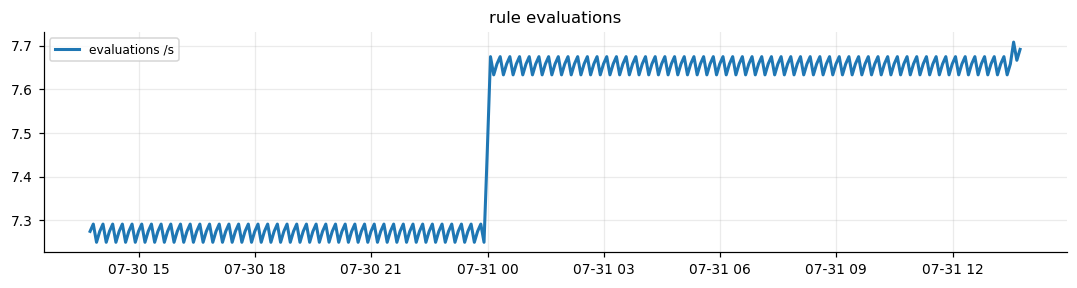

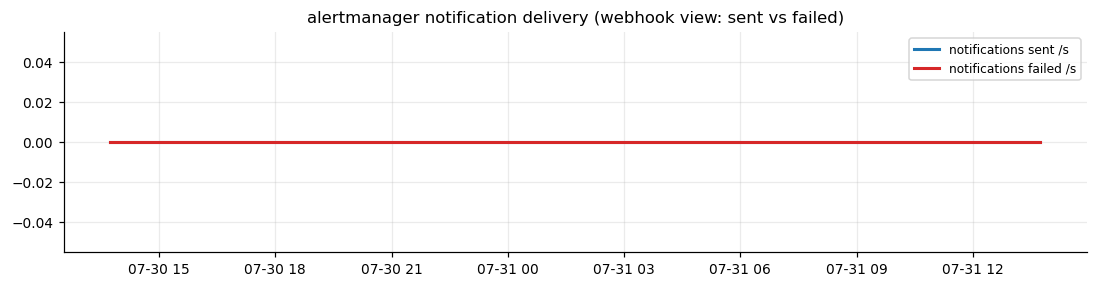

In [7]:
# --- RULER & ALERTMANAGER delivery ---
evals = f_evals['value'] if not f_evals.empty else pd.Series(dtype=float)
evalfail = f_evalfail['value'] if not f_evalfail.empty else pd.Series(dtype=float)
evalfail_max = float(evalfail.max()) if evalfail.notna().any() else 0.0
print(f"rule evaluations: {evals.mean():,.1f}/s mean; failures max {evalfail_max:.3f}/s")

notif_mean = {c: round(float(f_notif[c].mean()), 4) for c in f_notif.columns} if not f_notif.empty else {}
nfail = f_notif_fail['value'] if not f_notif_fail.empty else pd.Series(dtype=float)
notif_fail_max = float(nfail.max()) if nfail.notna().any() else 0.0
print(f"alertmanager notifications/s by integration (mean): {notif_mean}")
print(f"alertmanager notification failures: max {notif_fail_max:.4f}/s")

# Failure *ratio*, not just rate: 0.004 failures/s reads as trivial, but when it
# equals the send rate it means ~100% of alert notifications are failing. Frame it.
notif_total = f_notif.sum(axis=1) if not f_notif.empty else pd.Series(dtype=float)
notif_total_mean = float(notif_total.mean()) if not notif_total.empty else 0.0
notif_fail_mean = float(nfail.mean()) if nfail.notna().any() else 0.0
fail_ratio = notif_fail_mean / notif_total_mean if notif_total_mean > 0 else float('nan')
if notif_total_mean > 0:
    print(f"webhook delivery failure ratio (mimir view): {100 * min(fail_ratio, 1):.0f}% "
          f"({notif_fail_mean:.4f} failed/s of {notif_total_mean:.4f} sent/s)")

# Downstream truth from apprise itself (mimir only sees the webhook HTTP status):
deliv_total = float(f_deliv['value'].sum()) if not f_deliv.empty else 0.0
notsent_total = float(f_notsent['value'].sum()) if not f_notsent.empty else 0.0
print(f"apprise delivery ({lookback_hours}h): {deliv_total:.0f} fully-delivered, "
      f"{notsent_total:.0f} with >=1 target not sent")
if apprise_tail:
    print('recent apprise lines (the per-target reason lives here, not in mimir):')
    for ts, st, line in apprise_tail[:6]:
        print(f"  {ts:%d %H:%M:%S} {line[:140]}")

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(evals.index, evals, color='C0', lw=2, label='evaluations /s')
if evalfail_max > 0:
    ax.plot(evalfail.index, evalfail, color='C3', lw=2, label='failures /s')
ax.legend(fontsize=8)
ax.set_title('rule evaluations')
nbc.show(fig)

# alert delivery (mimir webhook view): sent vs failed -- the 1:1 line is the tell
fig, ax = plt.subplots(figsize=(12, 2.6))
if not notif_total.empty:
    ax.plot(notif_total.index, notif_total, color='C0', lw=2, label='notifications sent /s')
if nfail.notna().any():
    ax.plot(nfail.index, nfail, color='C3', lw=2, label='notifications failed /s')
ax.legend(fontsize=8)
ax.set_title('alertmanager notification delivery (webhook view: sent vs failed)')
nbc.show(fig)


In [8]:
# --- STORAGE: compactor recency ---
compactor_age_h = (cap.now - compactor_last) / 3600
print(f"compactor last successful run: {compactor_age_h:.1f}h ago")

compactor last successful run: 0.2h ago


In [9]:
# --- ALERTS (informational): two views of "what is firing" as a cross-check --
# the Alertmanager API (post-routing) vs the ruler's ALERTS series (pre-routing).
am_rows = [{'alertname': a['labels'].get('alertname', '?'),
            'namespace': a['labels'].get('namespace', ''),
            'state': a.get('status', {}).get('state', '?'),
            'since': a.get('startsAt', '')[:16]} for a in am_alerts]
am_df = pd.DataFrame(am_rows)
print(f"alertmanager: {len(am_df)} active alert instances now")
if not am_df.empty:
    print(am_df.groupby(['alertname', 'namespace', 'state']).agg(
        n=('since', 'size'), since=('since', 'min')).to_string())
metric_now = {(r['metric'].get('alertname', '?'), r['metric'].get('namespace', '')):
              int(float(r['value'][1])) for r in alerts_now}
print(f"ALERTS metric: {sum(metric_now.values())} firing series now "
      f"across {len(metric_now)} (alertname, namespace) pairs")

ns_24h = {r['metric'].get('alertname', '?'): int(float(r['value'][1])) for r in alerts_ns_24h}
print(f"fired in namespace '{namespace}' over trailing 24h: {ns_24h or 'none'}")
all_24h = pd.Series({f"{r['metric'].get('namespace', '-') or '-'}/{r['metric'].get('alertname', '?')}":
                     int(float(r['value'][1])) for r in alerts_all_24h}).sort_index()
print(f"cluster-wide over trailing 24h (context, not mimir findings):")
print(all_24h.to_string())

alertmanager: 6 active alert instances now
                                         n             since
alertname              namespace state                      
CiliumUnreachableNodes           active  5  2026-07-25T16:54
NodeDiskIOSaturation             active  1  2026-07-31T13:10
ALERTS metric: 6 firing series now across 2 (alertname, namespace) pairs
fired in namespace 'mimir' over trailing 24h: none
cluster-wide over trailing 24h (context, not mimir findings):
-/CiliumUnreachableNodes     5
-/NodeDiskIOSaturation       1
alloy/UnhealthyComponents    1


log lines/s by detected_level (mean over 24h): {'Info': 0.01, 'Warning': 0.0, 'error': 0.02, 'info': 7.63, 'unknown': 1.73, 'warn': 0.0}


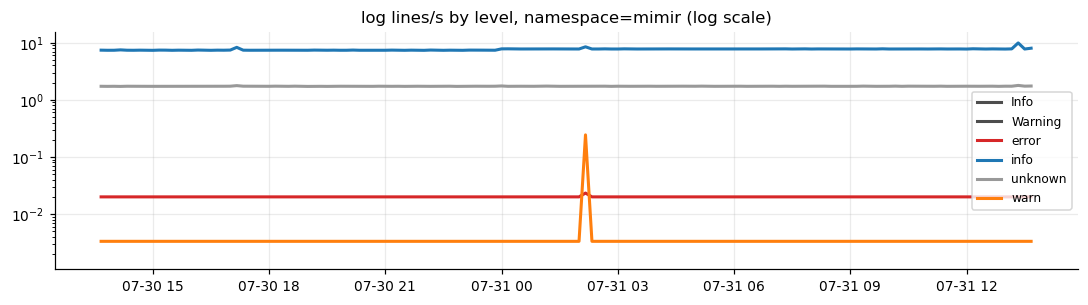

newest error/warn lines (up to 50 in 24h window, newest first):
  31 13:43:35 mimir-gateway-d47758865-tqlx 2026/07/31 13:43:35 [error] 11#11: *789148 open() "/etc/nginx/html/metrics" failed (2: No such file or directory), client: 10.0.148.192, server: , req
  31 13:42:35 mimir-gateway-d47758865-tqlx 2026/07/31 13:42:35 [error] 11#11: *789148 open() "/etc/nginx/html/metrics" failed (2: No such file or directory), client: 10.0.148.192, server: , req
  31 13:41:35 mimir-gateway-d47758865-tqlx 2026/07/31 13:41:35 [error] 11#11: *789148 open() "/etc/nginx/html/metrics" failed (2: No such file or directory), client: 10.0.148.192, server: , req
  31 13:40:35 mimir-gateway-d47758865-tqlx 2026/07/31 13:40:35 [error] 11#11: *789148 open() "/etc/nginx/html/metrics" failed (2: No such file or directory), client: 10.0.148.192, server: , req
  31 13:39:35 mimir-gateway-d47758865-tqlx 2026/07/31 13:39:35 [error] 11#11: *789148 open() "/etc/nginx/html/metrics" failed (2: No such file or directory), cl

In [10]:
# --- LOGS (Loki): volume by level, error/warn sample ---
lvl_colors = {'error': 'C3', 'warn': 'C1', 'info': 'C0', 'debug': 'C4', 'unknown': '0.6'}
lvl_rate_mean = {c: round(float(f_loglevel[c].mean() / 600), 2) for c in f_loglevel.columns}
print(f"log lines/s by detected_level (mean over {lookback_hours}h): {lvl_rate_mean}")

fig, ax = plt.subplots(figsize=(12, 2.8))
for c in f_loglevel.columns:
    ax.plot(f_loglevel.index, f_loglevel[c] / 600, lw=2, label=c,
            color=lvl_colors.get(c, '0.3'))
ax.legend(fontsize=8)
ax.set_yscale('log')
ax.set_title(f'log lines/s by level, namespace={namespace} (log scale)')
nbc.show(fig)

errish = sum(f_loglevel.get(lvl, pd.Series(dtype=float)).sum() for lvl in ('error', 'warn'))
if errish > 0 and not log_errwarn:
    print("WARNING: level counts report error/warn lines but the sample query returned "
          "none -- the sample query is broken, do not read this as 'no errors'")
print(f"newest error/warn lines (up to 50 in {lookback_hours}h window, newest first):")
for ts, st, line in log_errwarn[:30]:
    print(f"  {ts:%d %H:%M:%S} {st.get('pod', '?')[:28]:<28} {line[:150]}")
if len(log_errwarn) > 30:
    print(f"  ... {len(log_errwarn) - 30} more captured (see raw capture)")

In [11]:
# --- LOGS: raw tail sample -- unfiltered cross-check that collection is alive
# and that nothing odd hides below error/warn severity.
print(f"last {len(log_tail)} lines of anything from namespace={namespace}, newest first:")
for ts, st, line in log_tail:
    print(f"  {ts:%H:%M:%S} {st.get('pod', '?')[:28]:<28} {line[:150]}")

last 100 lines of anything from namespace=mimir, newest first:
  13:44:26 mimir-gateway-d47758865-tqlx 10.0.148.192 - - [31/Jul/2026:13:44:26 +0000]  200 "POST /api/v1/push HTTP/1.1" 0 "-" "Alloy/v1.17.1 (linux; helm)" "-"
  13:44:26 mimir-ruler-748b9f9c9c-zq4d7 ts=2026-07-31T13:44:26.07813449Z caller=query.go:88 method=Query.Exec user=tiles level=info msg="evaluation stats" estimatedPeakMemoryConsumption=9808
  13:44:26 mimir-ruler-748b9f9c9c-zq4d7 ts=2026-07-31T13:44:26.054888551Z caller=query.go:88 method=Query.Exec user=tiles level=info msg="evaluation stats" estimatedPeakMemoryConsumption=750
  13:44:26 mimir-ruler-748b9f9c9c-zq4d7 ts=2026-07-31T13:44:26.017552872Z caller=query.go:88 method=Query.Exec user=tiles level=info msg="evaluation stats" estimatedPeakMemoryConsumption=980
  13:44:26 mimir-gateway-d47758865-tqlx 10.0.148.20 - - [31/Jul/2026:13:44:26 +0000]  200 "GET /prometheus/config/v1/rules HTTP/1.1" 285192 "-" "Go-http-client/1.1" "-"
  13:44:25 mimir-gateway-d47758865-

In [12]:
# --- SUMMARY: assumption ledger first, then findings vs explicit thresholds ---
findings = []
if scrape_down:
    findings.append(f"scrape targets down: {scrape_down}")
if oom_pods:
    findings.append(f"last termination OOMKilled: {oom_pods}")
hot = {p: round(v, 0) for p, v in pods['mem_pct'].dropna().items() if v > 90}
if hot:
    findings.append(f"memory >90% of limit: {hot}")
if ring_bad:
    findings.append(f"unhealthy ring members: {ring_bad}")
sustained_err = {c: round(100 * float(err_nz[c].mean()), 2)
                 for c in err_nz.columns if 100 * err_nz[c].mean() > 1}
if sustained_err:
    findings.append(f"request error ratio >1% mean (mixin threshold): {sustained_err}")
if evalfail_max > 0:
    findings.append(f"rule evaluation failures present (max {evalfail_max:.3f}/s)")
if notif_fail_max > 0:
    findings.append(f"alertmanager notification failures (max {notif_fail_max:.4f}/s)")
if not apprise_pods or apprise_not_running:
    findings.append(f"delivery backend (apprise) not running: {apprise_not_running or 'no pods'}")
if notsent_total > 0 and deliv_total == 0:
    findings.append(f"alert delivery DOWN at apprise: {notsent_total:.0f} not-sent, 0 delivered in {lookback_hours}h")
elif notsent_total > 0:
    findings.append(f"alert delivery degraded at apprise: {notsent_total:.0f} not-sent vs {deliv_total:.0f} delivered in {lookback_hours}h")
if notif_total_mean > 0 and fail_ratio > 0.5:
    findings.append(f"webhook notification failure ratio {100 * min(fail_ratio, 1):.0f}% (mimir view)")
if compactor_age_h > 24:
    findings.append(f"compactor last success {compactor_age_h:.0f}h ago (>24h)")
if ns_24h:
    findings.append(f"alerts fired in namespace {namespace} in 24h: {sorted(ns_24h)}")

print("=" * 60)
print("MIMIR HEALTH SUMMARY")
print("=" * 60)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"mimir:    {mimir_version}, tenant {tenant}, lookback {lookback_hours}h")
print()
print("Assumptions: " + ("all instruments fresh" if not assumption_warnings
                         else "; ".join(assumption_warnings)))
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- all within thresholds")
print()
print(f"  Components: {len(pods)} pods; scrape down {scrape_down or 'none'}; "
      f"ring {ring_bad or 'healthy'}")
print(f"  Ruler:      eval failures max {evalfail_max:.3f}/s; "
      f"notif failures max {notif_fail_max:.4f}/s")
print(f"  Delivery:   apprise {len(apprise_pods) - len(apprise_not_running)}/{len(apprise_pods)} up; "
      f"{deliv_total:.0f} delivered / {notsent_total:.0f} not-sent ({lookback_hours}h)")
print(f"  Storage:    compactor ok {compactor_age_h:.1f}h ago")
print(f"  Alerts:     {len(am_df)} active now (cluster-wide); "
      f"{namespace}-ns 24h: {sorted(ns_24h) or 'none'}")
print(f"  Logs:       {lvl_rate_mean} lines/s by level")

MIMIR HEALTH SUMMARY
run:      2026-07-31T13:44:26.371756+00:00  (live)
mimir:    3.0.1, tenant tiles, lookback 24h

Assumptions: all instruments fresh

Findings:
  ! scrape targets down: ['mimir/gateway']
  ! alert delivery degraded at apprise: 4466 not-sent vs 2 delivered in 24h

  Components: 20 pods; scrape down ['mimir/gateway']; ring healthy
  Ruler:      eval failures max 0.000/s; notif failures max 0.0000/s
  Delivery:   apprise 1/1 up; 2 delivered / 4466 not-sent (24h)
  Storage:    compactor ok 0.2h ago
  Alerts:     6 active now (cluster-wide); mimir-ns 24h: none
  Logs:       {'Info': 0.01, 'Warning': 0.0, 'error': 0.02, 'info': 7.63, 'unknown': 1.73, 'warn': 0.0} lines/s by level


In [13]:
# AGENT-READABLE STATS -- consolidated JSON; assumption status leads so a reader
# calibrates trust before any verdict.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'mimir_version': mimir_version,
    'lookback_hours': lookback_hours,
    'assumptions': {
        'status': 'ok' if not assumption_warnings else 'degraded',
        'warnings': assumption_warnings,
        'instrument_age_s': {k: _n(v) for k, v in inst_age.items()},
    },
    'findings': findings,
    'components': {
        'scrape_down': scrape_down,
        'restarts_by_pod': restart_pods,
        'oom_last_term': oom_pods,
        'mem_pct_of_limit': {p: _n(v) for p, v in pods['mem_pct'].dropna().items()},
        'ring_unhealthy': ring_bad,
    },
    'request_errors': {'max_pct_by_route': err_worst},
    'ruler': {'eval_per_s_mean': _n(evals.mean()),
              'eval_failures_per_s_max': _n(evalfail_max)},
    'alertmanager': {'notifications_per_s_mean_by_integration': notif_mean,
                     'failures_per_s_max': _n(notif_fail_max),
                     'failure_ratio_pct': _n(100 * fail_ratio) if notif_total_mean > 0 else None},
    'delivery_backend': {
        'apprise_pods_running': f"{len(apprise_pods) - len(apprise_not_running)}/{len(apprise_pods)}",
        'apprise_not_running': apprise_not_running,
        'restarts_by_pod': apprise_restart_pods,
        'delivered_in_window': int(deliv_total),
        'not_sent_in_window': int(notsent_total),
        'recent_lines': [f"{ts:%Y-%m-%d %H:%M:%S} {line[:150]}"
                         for ts, st, line in apprise_tail[:6]],
    },
    'storage': {'compactor_last_success_age_h': _n(compactor_age_h)},
    'alerts': {
        'active_now': sorted({f"{r['namespace'] or '-'}/{r['alertname']}" for r in am_rows}),
        'metric_firing_series_now': int(sum(metric_now.values())),
        'namespace_24h': ns_24h,
        'cluster_24h': {k: int(v) for k, v in all_24h.items()},
    },
    'logs': {
        'lines_per_s_mean_by_level': lvl_rate_mean,
        'errwarn_captured': len(log_errwarn),
        'errwarn_newest': [f"{ts:%Y-%m-%d %H:%M:%S} {st.get('pod', '?')} {line[:150]}"
                           for ts, st, line in log_errwarn[:10]],
    },
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "mimir-health.ipynb",
 "run_at": "2026-07-31T13:44:26.371756+00:00",
 "mode": "live",
 "mimir_version": "3.0.1",
 "lookback_hours": 24,
 "assumptions": {
  "status": "ok",
  "warnings": [],
  "instrument_age_s": {
   "cortex self-monitoring": 3.9458,
   "kube-state-metrics (mimir ns)": 53.4938,
   "cadvisor (mimir ns)": 12.1138,
   "loki (mimir ns logs)": 0.2613
  }
 },
 "findings": [
  "scrape targets down: ['mimir/gateway']",
  "alert delivery degraded at apprise: 4466 not-sent vs 2 delivered in 24h"
 ],
 "components": {
  "scrape_down": [
   "mimir/gateway"
  ],
  "restarts_by_pod": {
   "mimir-ingester-0": 9,
   "mimir-ingester-1": 2,
   "mimir-store-gateway-0": 2,
   "mimir-distributor-7ccf8d9fdf-lc5x7": 3,
   "mimir-querier-5fffc97669-sktsb": 3,
   "mimir-compactor-0": 1,
   "mimir-query-scheduler-78b7cd94b4-98vdg": 1,
   "mimir-ruler-748b9f9c9c-gzxbw": 17
  },
  "oom_last_term": [],
  "mem_pct_of_limit": {
   "mimir-alertmanager-0": 32.988,
   "mimir-rollout-opera